# Results Window
- GPR19 shows that because of the datapoint clumping the model can be made more confident that the data is constant if it starts predicting after one of them. 
- We can try downsampling by enforcing a minimum cadence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import emcee

from scipy.optimize import minimize
from scipy.special import softmax

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

from scipy.stats import norm

import sys
from pathlib import Path
from IPython.display import display as ipy_display

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

def build_kernel(params, kernel_types):
    """Build a celerite2 kernel from a parameter array and kernel type list.
    
    params layout: [sigmas (all terms), rhos (all terms), qs (SHO terms only)]
    """
    n = len(kernel_types)
    sigmas = params[0:n]
    rhos   = params[n:2*n]
    qs     = params[2*n:]  # only SHO terms, in order

    kernel = None
    sho_idx = 0
    for i, ktype in enumerate(kernel_types):
        if ktype == 'sho':
            term = terms.SHOTerm(sigma=sigmas[i], rho=rhos[i], Q=qs[sho_idx])
            sho_idx += 1
        else:
            term = terms.Matern32Term(sigma=sigmas[i], rho=rhos[i])
        kernel = term if kernel is None else kernel + term
    return kernel

def set_params(log_params, kernel_types, gp):
    gp.kernel = build_kernel(np.exp(log_params), kernel_types)
    return gp

def NLL(log_params, gp, kernel_types, y):
    gp = set_params(log_params, kernel_types, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def forward_NLPD(log_params, gp, kernel_types, inner_train_df, inner_fwd_df, error_percent):
    gp = set_params(log_params, kernel_types, gp)
    inner_yerr = inner_train_df['sind'] * error_percent / 100
    try:
        gp.compute(inner_train_df['day'], yerr=inner_yerr)
        mu, cov = gp.predict(inner_train_df['sind'], t=inner_fwd_df['day'], return_var=True)
    except Exception:
        return np.inf
    y = inner_fwd_df['sind'].to_numpy()
    fwd_yerr = (inner_fwd_df['sind'] * error_percent / 100).to_numpy()
    total_var = cov + fwd_yerr**2
    nlpd = 0.5 * np.log(2 * np.pi * total_var) + (y - mu)**2 / (2 * total_var)
    val = nlpd.mean()
    return val if np.isfinite(val) else np.inf

def lnPost(log_params, gp, kernel_types, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, kernel_types, gp)
    gp.recompute(quiet=True)
    ll = gp.log_likelihood(y)
    if not np.isfinite(ll):
        return -np.inf
    return ll - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

def plot_trace(sampler, param_names=None):
    samples = sampler.get_chain()  # shape: (n_steps, n_walkers, n_params)
    n_steps, n_walkers, n_params = samples.shape

    if param_names is None:
        param_names = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.5 * n_params), sharex=True)
    if n_params == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        ax.plot(np.exp(samples[:, :, i]), color="steelblue", alpha=0.3, lw=0.7)
        ax.set_ylabel(param_names[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step")
    axes[0].set_title("MCMC Trace")
    fig.tight_layout()
    ipy_display(fig)
    plt.close(fig)

# Check if constant
def check_constant(predictions, MAD, tol = 2, percentile = 84):
    '''
    Helper function to check if the variations in a forecast is not significant compared to the noise.
    Noise is defined by the MAD of the training set.
    t0 is the actual prediction start point

    Returns true if constant within 1std.
    '''
    amps = predictions.max(axis=1) - predictions.min(axis=1)

    return np.percentile(amps, percentile) / MAD < tol

def best_in_x(predictions, t, lookahead_years, t_start=None):
    '''
    Takes a look at the predictions starting at the start of prediction time t0.
    Finds the lowest predicted SInd in the next 'years' years.
    If years > prediction range, warn and then give the best in the prediction range.
    This is regardless of which the first peak is.

    Inputs
        t are the days at which the predictions are rpedicted
        Years is the lookahead

    Return time relative to start of predictions of the best time.
    '''  
    t_start = t_start if t_start is not None else t[0]

    lookahead_days = lookahead_years * 365

    t_end = t_start + lookahead_days
    if t_end > t[-1]:
        t_end = t[-1]
        # Warn
        print("t_end is after the end of the predictions. Extend prediction window!")

    # Get the predictions that are before t_end
    mask = (t >= t_start) & (t < t_end)
    window_predictions = predictions[:,mask]
    window_t = t[mask]

    # Get the minima from each posterior-sampled prediction
    min_t = window_t[np.argmin(window_predictions, axis=1)]
    median_min_t = np.median(min_t)
    lb_min_t, hb_min_t = np.percentile(min_t, [16,84])

    return median_min_t, (lb_min_t, hb_min_t)

# Adding the gaussian smoothing                                                                                                    
def gaussian_smooth(t, y, sigma, n_eval=1000):                                                                                             
    t_eval = np.linspace(t.min(), t.max(), n_eval)                                                                                        
    w = np.exp(-0.5 * ((t[:, None] - t_eval[None, :]) / sigma) ** 2)                                                                       
    return t_eval, (w * y[:, None]).sum(axis=0) / w.sum(axis=0)          

def truth_in_x(data_df, year_ref, day_ref, t0_year, lookahead_years,
               pred_start_day=None, span_multiplier=0.04, recency_halflife_years=3):
    '''
    Returns a single best-time estimate for the ground truth minimum within the lookahead window.
    Recent data (close to pred_start_day) is upweighted exponentially.
    '''
    span = data_df['day'].max() - data_df['day'].min()
    sigma = span * span_multiplier

    t_days = data_df['day'].values
    y = data_df['sind'].values

    # Exponential upweighting of data closer to the prediction start
    if pred_start_day is not None:
        halflife_days = recency_halflife_years * 365
        recency_weights = np.exp(-np.maximum(0, pred_start_day - t_days) * np.log(2) / halflife_days)
    else:
        recency_weights = np.ones(len(t_days))

    t_eval = np.linspace(t_days.min(), t_days.max(), 1000)
    w = np.exp(-0.5 * ((t_days[:, None] - t_eval[None, :]) / sigma) ** 2)
    w = w * recency_weights[:, None]
    y_s = (w * y[:, None]).sum(axis=0) / w.sum(axis=0)
    t_year_s = year_ref + (t_eval - day_ref) / 365

    window_mask = (t_year_s >= t0_year) & (t_year_s <= t0_year + lookahead_years)
    if not window_mask.any():
        return np.nan

    return t_year_s[window_mask][np.argmin(y_s[window_mask])]


def downsample_min_gap(df, minimum_gap):
    days = df["day"].values
    keep = np.zeros(len(days), dtype=bool)
    keep[0] = True
    last_kept = days[0]
    for i in range(1, len(days)):
        if days[i] - last_kept >= minimum_gap:
            keep[i] = True
            last_kept = days[i]
    return df[keep].reset_index(drop=True)


In [2]:
# ---- PARAMS ----
datapath            = r"../../Data/mwd/hd221115_caii.txt"
direct_bound_tol    = 0.1
sm2016_bound_tol    = 0.2
mean_bound_tol      = 1
add_prefix          = False
relative            = True
train_split         = 0.6
valid_split         = 0.15 
star_type           = "G"
star_name           = "HD201091"
error_percent       = 2.5
sigma_upper_mult    = 5.0
q_bounds_in         = [1, 5]  # THIS HAS BEEN CHANGED
verbose             = True
plot                = True
loop_verbose        = True
loop_plot           = True
loop_savefigs       = False
sampler_plot        = True
result_plot_cadence = 50
result_plot_extra   = 1000
require_mid         = True
total_sample_count  = 2500
plot_every          = 200
subsample           = 500
n_walkers           = 32
valid_metric        = "CRPS"
inner_train_fracs   = [0.6, 0.7, 0.8, 0.9]  # optimise over each; keep best by forward NLPD
SEED                = 1701

In [3]:
#------Ingest and prep data-----
raw_df   = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
data_df  = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Check datapoints
if len(data_df) < 100:
    print("Data has less than 100 datapoints.")
    # SKIP DATASET

# Check span
span = data_df['year'].iloc[-1] - data_df['year'].iloc[0]
if span < 1:
    print("Data spans less than 1 year!")
    # SKIP DATASET

# Check gaps
gaps = data_df['year'].diff().dropna()
if max(gaps) > (span/10):
    print("Biggest gap is greater than 10% of span!")

Gap distribution (days):
  Min:  0.0
  p25: 0.0
  p50: 0.0
  p75: 3.9
  p90: 9.0
  p95: 16.9
  p99: 215.1
  Max:  379.1


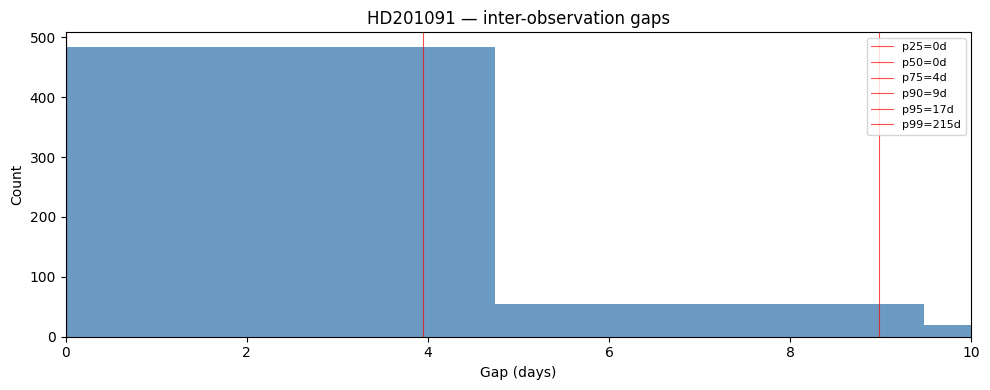

In [4]:
# Dist of cadences
gaps_days = np.diff(data_df['day'].values)

percentiles = [25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(gaps_days, percentiles)

print("Gap distribution (days):")
print(f"  Min:  {gaps_days.min():.1f}")
for p, v in zip(percentiles, pct_vals):
    print(f"  p{p:02d}: {v:.1f}")
print(f"  Max:  {gaps_days.max():.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gaps_days, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
for p, v in zip(percentiles, pct_vals):
    ax.axvline(v, color="red", lw=0.8, alpha=0.7, label=f"p{p}={v:.0f}d")
ax.set_xlabel("Gap (days)")
ax.set_ylabel("Count")
ax.set_title(f"{star_name} — inter-observation gaps")
ax.legend(fontsize=8)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

In [5]:
# Downsample to minimum gap
minimum_gap = 2.5  # days

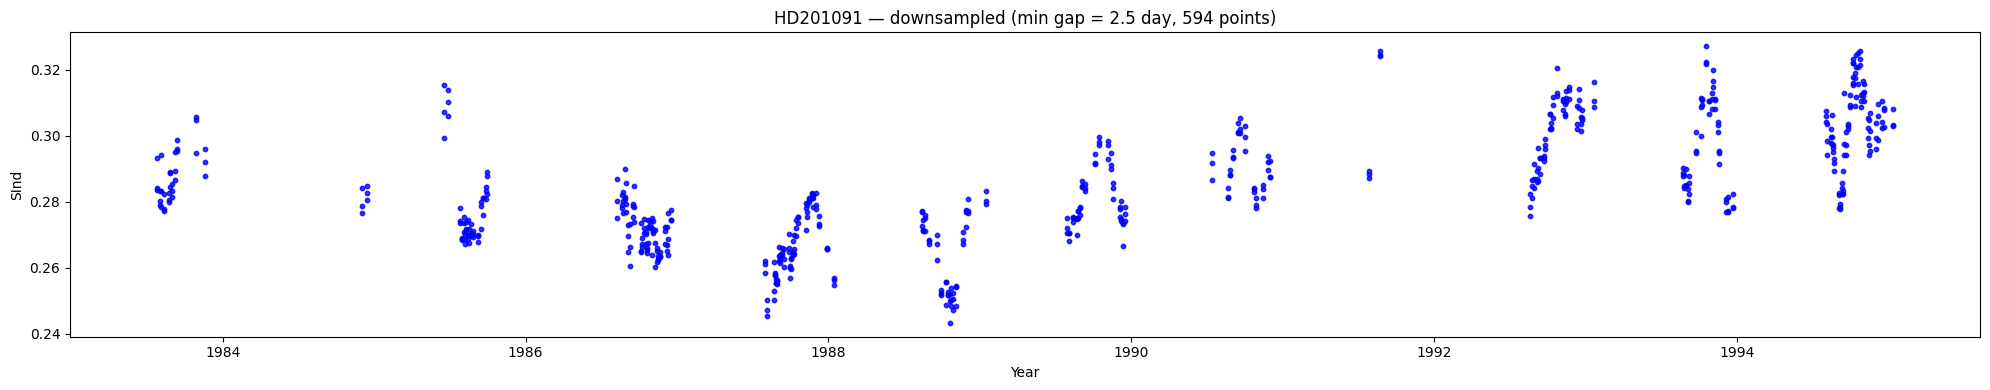

In [6]:
# Plot the downsample
fig, ax = plt.subplots(figsize=(20, 4))
ax.scatter(data_df["year"], data_df["sind"], s=10, alpha=0.8, color="blue")
ax.set_xlabel("Year")
ax.set_ylabel("SInd")
ax.set_title(f"{star_name} — downsampled (min gap = {minimum_gap} day, {len(data_df)} points)")
plt.tight_layout()
plt.show()

- If we split by span, there is no guarantee that there will be points in every split.
- Instead, we can split by datapoints but also have a minimum span.

+--------+-------------+-------------+------------+-----------+-------------+
| Window | Train Split | Valid Split | Test Split | Train Idx | Retrain Idx |
+--------+-------------+-------------+------------+-----------+-------------+
|   1    |    0.150    |    0.325    |   0.525    |     89    |     282     |
|   2    |    0.300    |    0.271    |   0.429    |    178    |     339     |
|   3    |    0.450    |    0.186    |   0.364    |    267    |     378     |
|   4    |    0.600    |    0.147    |   0.253    |    356    |     444     |
+--------+-------------+-------------+------------+-----------+-------------+


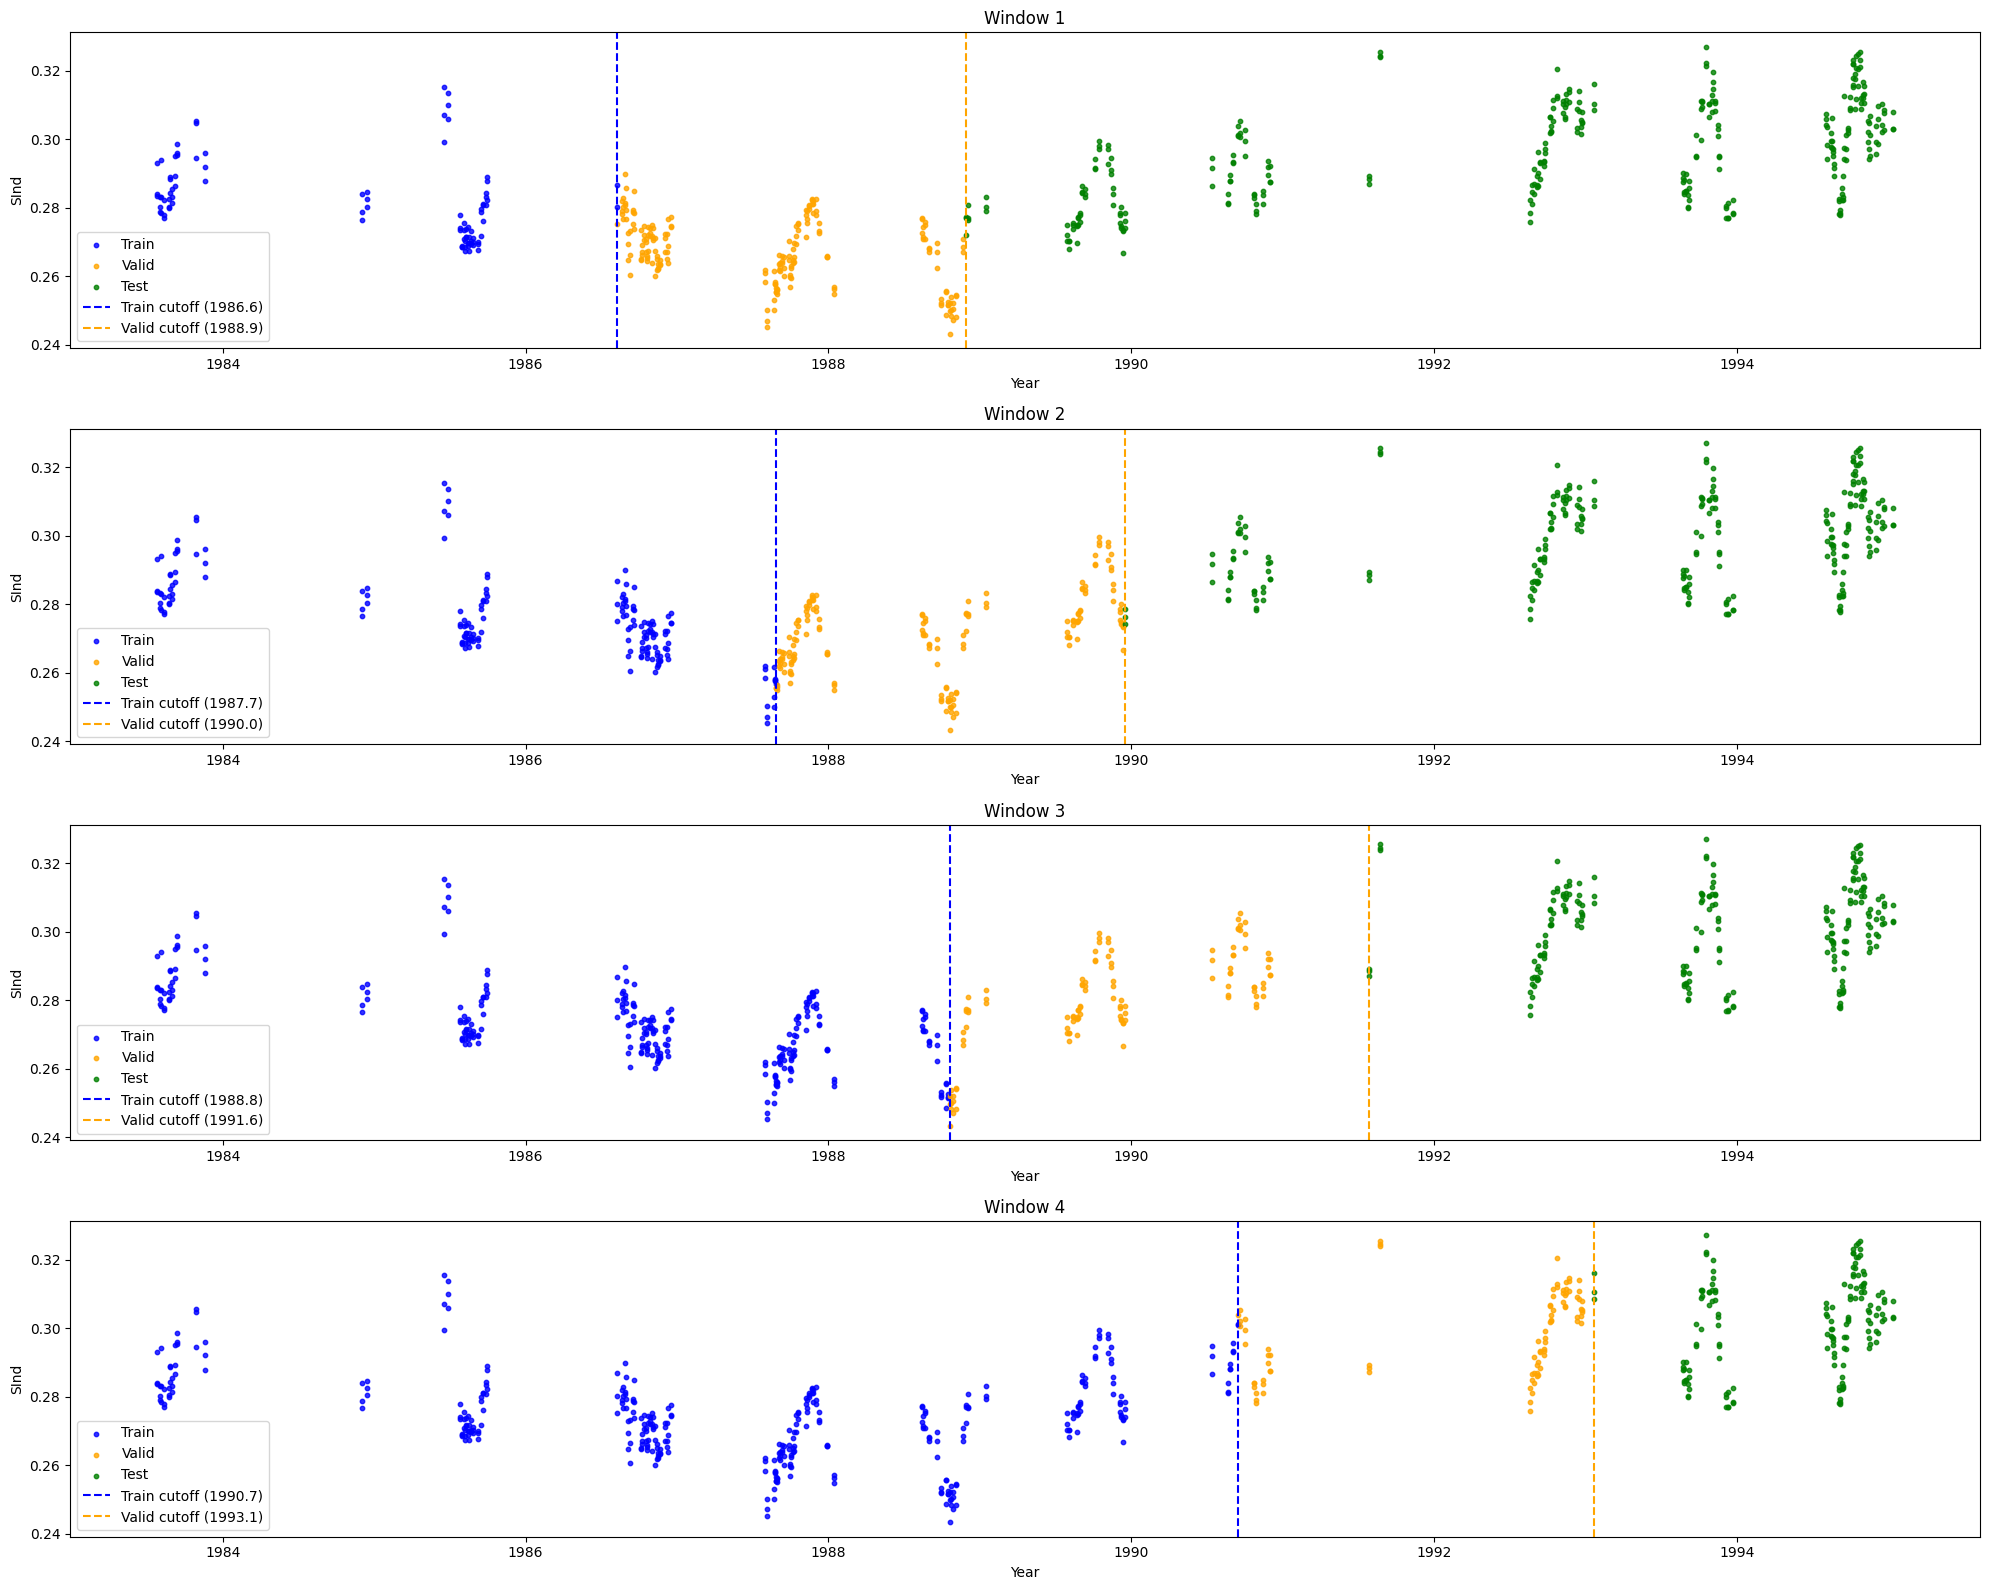

In [7]:
n_windows = 5 #  Targeted number of windows

# Minimum train_split is the larger of 0.75/n_windows or 15% of span
divide_train_splits = [(0.75 / n_windows) * n for n in range(1,n_windows+1)] 
span_train_split = (data_df['year'] < data_df['year'].iloc[0] + 0.15 * span).sum() / len(data_df) # Gets the frac to make it cover 15% of the span
raw_train_splits = np.maximum(divide_train_splits, span_train_split)
train_splits = np.unique(raw_train_splits) # Makes sure they are unique; leaves min of 1
train_idxs = np.round(len(data_df) * train_splits).astype(int)

# Validation split is the either 0.1 of points or frac giving at leas 10% of span
hard_valid_split = 0.15
span_valid_splits = np.array([ 
      (data_df['year'] < data_df['year'].iloc[idx] + 0.2 * span).sum() / len(data_df) - ts
      for idx, ts in zip(train_idxs, train_splits)
  ])
valid_splits = np.maximum(0.1, span_valid_splits) # Validation fractions
valid_idxs = np.round(len(data_df) * valid_splits).astype(int)

# Check if any remains
retraining_split = train_splits + valid_splits # just a diagnostic to see if less than 1; retraining will make sense later
mask = retraining_split < 1 
valid_splits = valid_splits[mask]
train_splits = train_splits[mask]
retraining_split = retraining_split[mask]
train_idxs = train_idxs[mask]
valid_idxs = valid_idxs[mask]

# Remaining is test and remove any with a span of less than 1 year
retraining_idxs = train_idxs + valid_idxs
mask_in_bounds = retraining_idxs < len(data_df)

retraining_idxs = retraining_idxs[mask_in_bounds]
train_idxs = train_idxs[mask_in_bounds]
valid_idxs = valid_idxs[mask_in_bounds]
train_splits = train_splits[mask_in_bounds]
valid_splits = valid_splits[mask_in_bounds]
test_splits = (1 - retraining_split)[mask_in_bounds]


# If empty, skip the dataset
if len(test_splits) < 1:
    test_split = (data_df['year'] >= data_df['year'].iloc[-1] - 1).sum() / len(data_df)
    remaining = 1 - test_split
    retrain_end_idx = int(np.round(len(data_df) * remaining)) - 1
    if data_df['year'].iloc[retrain_end_idx] - data_df['year'].iloc[0] < 1:
        print("WARNING: Combined train+valid span < 1 year. Skipping dataset.")
    else:
        print("WARNING: No valid splits, using fallback: 1yr test, 50/50 train/valid.")
        train_splits = np.array([remaining / 2])
        valid_splits = np.array([remaining / 2])
        test_splits = np.array([test_split])
        train_idxs = np.round(len(data_df) * train_splits).astype(int)
        valid_idxs = np.round(len(data_df) * valid_splits).astype(int)
        retraining_idxs = train_idxs + valid_idxs

# Make sure they sum to 1
split_totals = test_splits + train_splits + valid_splits
if not np.all(np.isclose(split_totals, 1)):
    print("ERROR: SPLITS DO NOT SUM TO 1")

verbose_split = True
if verbose_split:
    table = PrettyTable()
    table.field_names = ["Window", "Train Split", "Valid Split", "Test Split", "Train Idx", "Retrain Idx"]
    for i, (tr, v, te, ti, ri) in enumerate(zip(train_splits, valid_splits, test_splits, train_idxs, retraining_idxs)):
        table.add_row([i+1, f"{tr:.3f}", f"{v:.3f}", f"{te:.3f}", ti, ri])
    print(table)

plot_split = True
if plot_split:
    n_wins = len(train_splits)
    fig, axes = plt.subplots(n_wins, 1, figsize=(20, 4 * n_wins), sharex=False)
    if n_wins == 1:
        axes = [axes]

    years = data_df['year'].values
    sinds = data_df['sind'].values

    for i, ax in enumerate(axes):
        train_year = years[train_idxs[i]]
        retrain_year = years[retraining_idxs[i]]

        ax.scatter(years[:train_idxs[i]], sinds[:train_idxs[i]], s=10, alpha=0.8, color='blue', label='Train')
        ax.scatter(years[train_idxs[i]:retraining_idxs[i]], sinds[train_idxs[i]:retraining_idxs[i]], s=10, alpha=0.8, color='orange', label='Valid')
        ax.scatter(years[retraining_idxs[i]:], sinds[retraining_idxs[i]:], s=10, alpha=0.8, color='green', label='Test')

        ax.axvline(train_year,   color='blue',   linestyle='--', label=f'Train cutoff ({train_year:.1f})')
        ax.axvline(retrain_year, color='orange', linestyle='--', label=f'Valid cutoff ({retrain_year:.1f})')

        ax.set_xlabel("Year")
        ax.set_ylabel("SInd")
        ax.set_title(f"Window {i+1}")
        ax.legend()

plt.tight_layout()
plt.show()

- Now define the test windows from the test set length.

In [8]:
test_windows = [] # List of lists of test windows corresponding to each split

test_t0s = data_df['year'].iloc[retraining_idxs - 1].to_numpy()
t_end = data_df['year'].iloc[-1]
test_spans = t_end - test_t0s
# These are what each set should have lookahead windows for (full span appended inside loop)
test_window_intervalss = [np.concatenate([[1] * int(np.floor(test_span))]) for test_span in test_spans]
test_window_lenss = [np.cumsum(test_window_intervals) for test_window_intervals in test_window_intervalss]

- Now we have train_splits, valid_splits, and test_splits.
- Peform model selection process and retraining on the splits and use the test_window_lenss as lookahead tests.
- Now must loop through the splits, running GPR18 on each.

In [9]:
verbose_clean = False
plot_clean = False
plot_fitpeaks = False
verbose_fitpeaks = False
plot_genpriors = False
verbose_genpriors = False
plot_comparison = False
verbose_comparison = False
verbose_selected = True
plot_sampler = False


pred_forward_years = 2

low_cad = 30
high_cad = 10

min_gap = 3

+------------+------------+-------------+--------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |    Bounds Days     |  Bounds Years  | Source |
+------------+------------+-------------+--------------------+----------------+--------+
|   Short    |   19.60    |     0.05    |   (8.50, 30.70)    |  (0.02, 0.08)  |  mean  |
|    Mid     |  2445.50   |     6.70    | (1131.50, 3759.50) | (3.10, 10.30)  |  mean  |
|    Long    |  36500.00  |    100.00   |  (1.00, 73000.00)  | (0.00, 200.00) |  mean  |
+------------+------------+-------------+--------------------+----------------+--------+
Selected model: 3sml (CRPS=0.0083)


  0%|          | 0/2500 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2500/2500 [00:09<00:00, 277.54it/s]


100/500
200/500
300/500
400/500
500/500
t_end is after the end of the predictions. Extend prediction window!
+----------------+-------------+-----------+--------------+
| Label          | Search from | Search to | Ground truth |
+----------------+-------------+-----------+--------------+
| Best in +1.0yr |     1988.91 |   1989.91 |      1988.92 |
| Best in +2.0yr |     1988.91 |   1990.91 |      1988.92 |
| Best in +3.0yr |     1988.91 |   1991.91 |      1988.92 |
| Best in +4.0yr |     1988.91 |   1992.91 |      1988.92 |
| Best in +5.0yr |     1988.91 |   1993.91 |      1988.92 |
| Best in +6.0yr |     1988.91 |   1994.91 |      1988.92 |
| Best in +6.1yr |     1988.91 |   1995.03 |      1988.92 |
+----------------+-------------+-----------+--------------+
+------------+------------+-------------+------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |   Bounds Days    |  Bounds Years  | Source |
+------------+------------+-------------+----------------

  0%|          | 0/2500 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2500/2500 [00:07<00:00, 315.92it/s]


100/500
200/500
300/500
400/500
500/500
t_end is after the end of the predictions. Extend prediction window!
+----------------+-------------+-----------+--------------+
| Label          | Search from | Search to | Ground truth |
+----------------+-------------+-----------+--------------+
| Best in +1.0yr |     1989.94 |   1990.94 |      1989.95 |
| Best in +2.0yr |     1989.94 |   1991.94 |      1989.95 |
| Best in +3.0yr |     1989.94 |   1992.94 |      1989.95 |
| Best in +4.0yr |     1989.94 |   1993.94 |      1989.95 |
| Best in +5.0yr |     1989.94 |   1994.94 |      1989.95 |
| Best in +5.1yr |     1989.94 |   1995.03 |      1989.95 |
+----------------+-------------+-----------+--------------+
+------------+------------+-------------+------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |   Bounds Days    |  Bounds Years  | Source |
+------------+------------+-------------+------------------+----------------+--------+
|   Short    |    0.00    |   

  0%|          | 0/2500 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2500/2500 [00:08<00:00, 295.96it/s]


100/500
200/500
300/500
400/500
500/500
t_end is after the end of the predictions. Extend prediction window!
+----------------+-------------+-----------+--------------+
| Label          | Search from | Search to | Ground truth |
+----------------+-------------+-----------+--------------+
| Best in +1.0yr |     1990.87 |   1991.87 |      1990.88 |
| Best in +2.0yr |     1990.87 |   1992.87 |      1990.88 |
| Best in +3.0yr |     1990.87 |   1993.87 |      1990.88 |
| Best in +4.0yr |     1990.87 |   1994.87 |      1990.88 |
| Best in +4.2yr |     1990.87 |   1995.03 |      1990.88 |
+----------------+-------------+-----------+--------------+
+------------+------------+-------------+--------------------+----------------+--------+
| Cycle Type | Prior Days | Prior Years |    Bounds Days     |  Bounds Years  | Source |
+------------+------------+-------------+--------------------+----------------+--------+
|   Short    |   145.01   |     0.40    |  (130.51, 159.51)  |  (0.36, 0.44)  | foun

  0%|          | 0/2500 [00:00<?, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2500/2500 [00:09<00:00, 269.28it/s]


100/500
200/500
300/500
400/500
500/500
t_end is after the end of the predictions. Extend prediction window!
+----------------+-------------+-----------+--------------+
| Label          | Search from | Search to | Ground truth |
+----------------+-------------+-----------+--------------+
| Best in +1.0yr |     1992.73 |   1993.73 |      1993.72 |
| Best in +2.0yr |     1992.73 |   1994.73 |      1993.83 |
| Best in +2.3yr |     1992.73 |   1995.03 |      1993.83 |
+----------------+-------------+-----------+--------------+


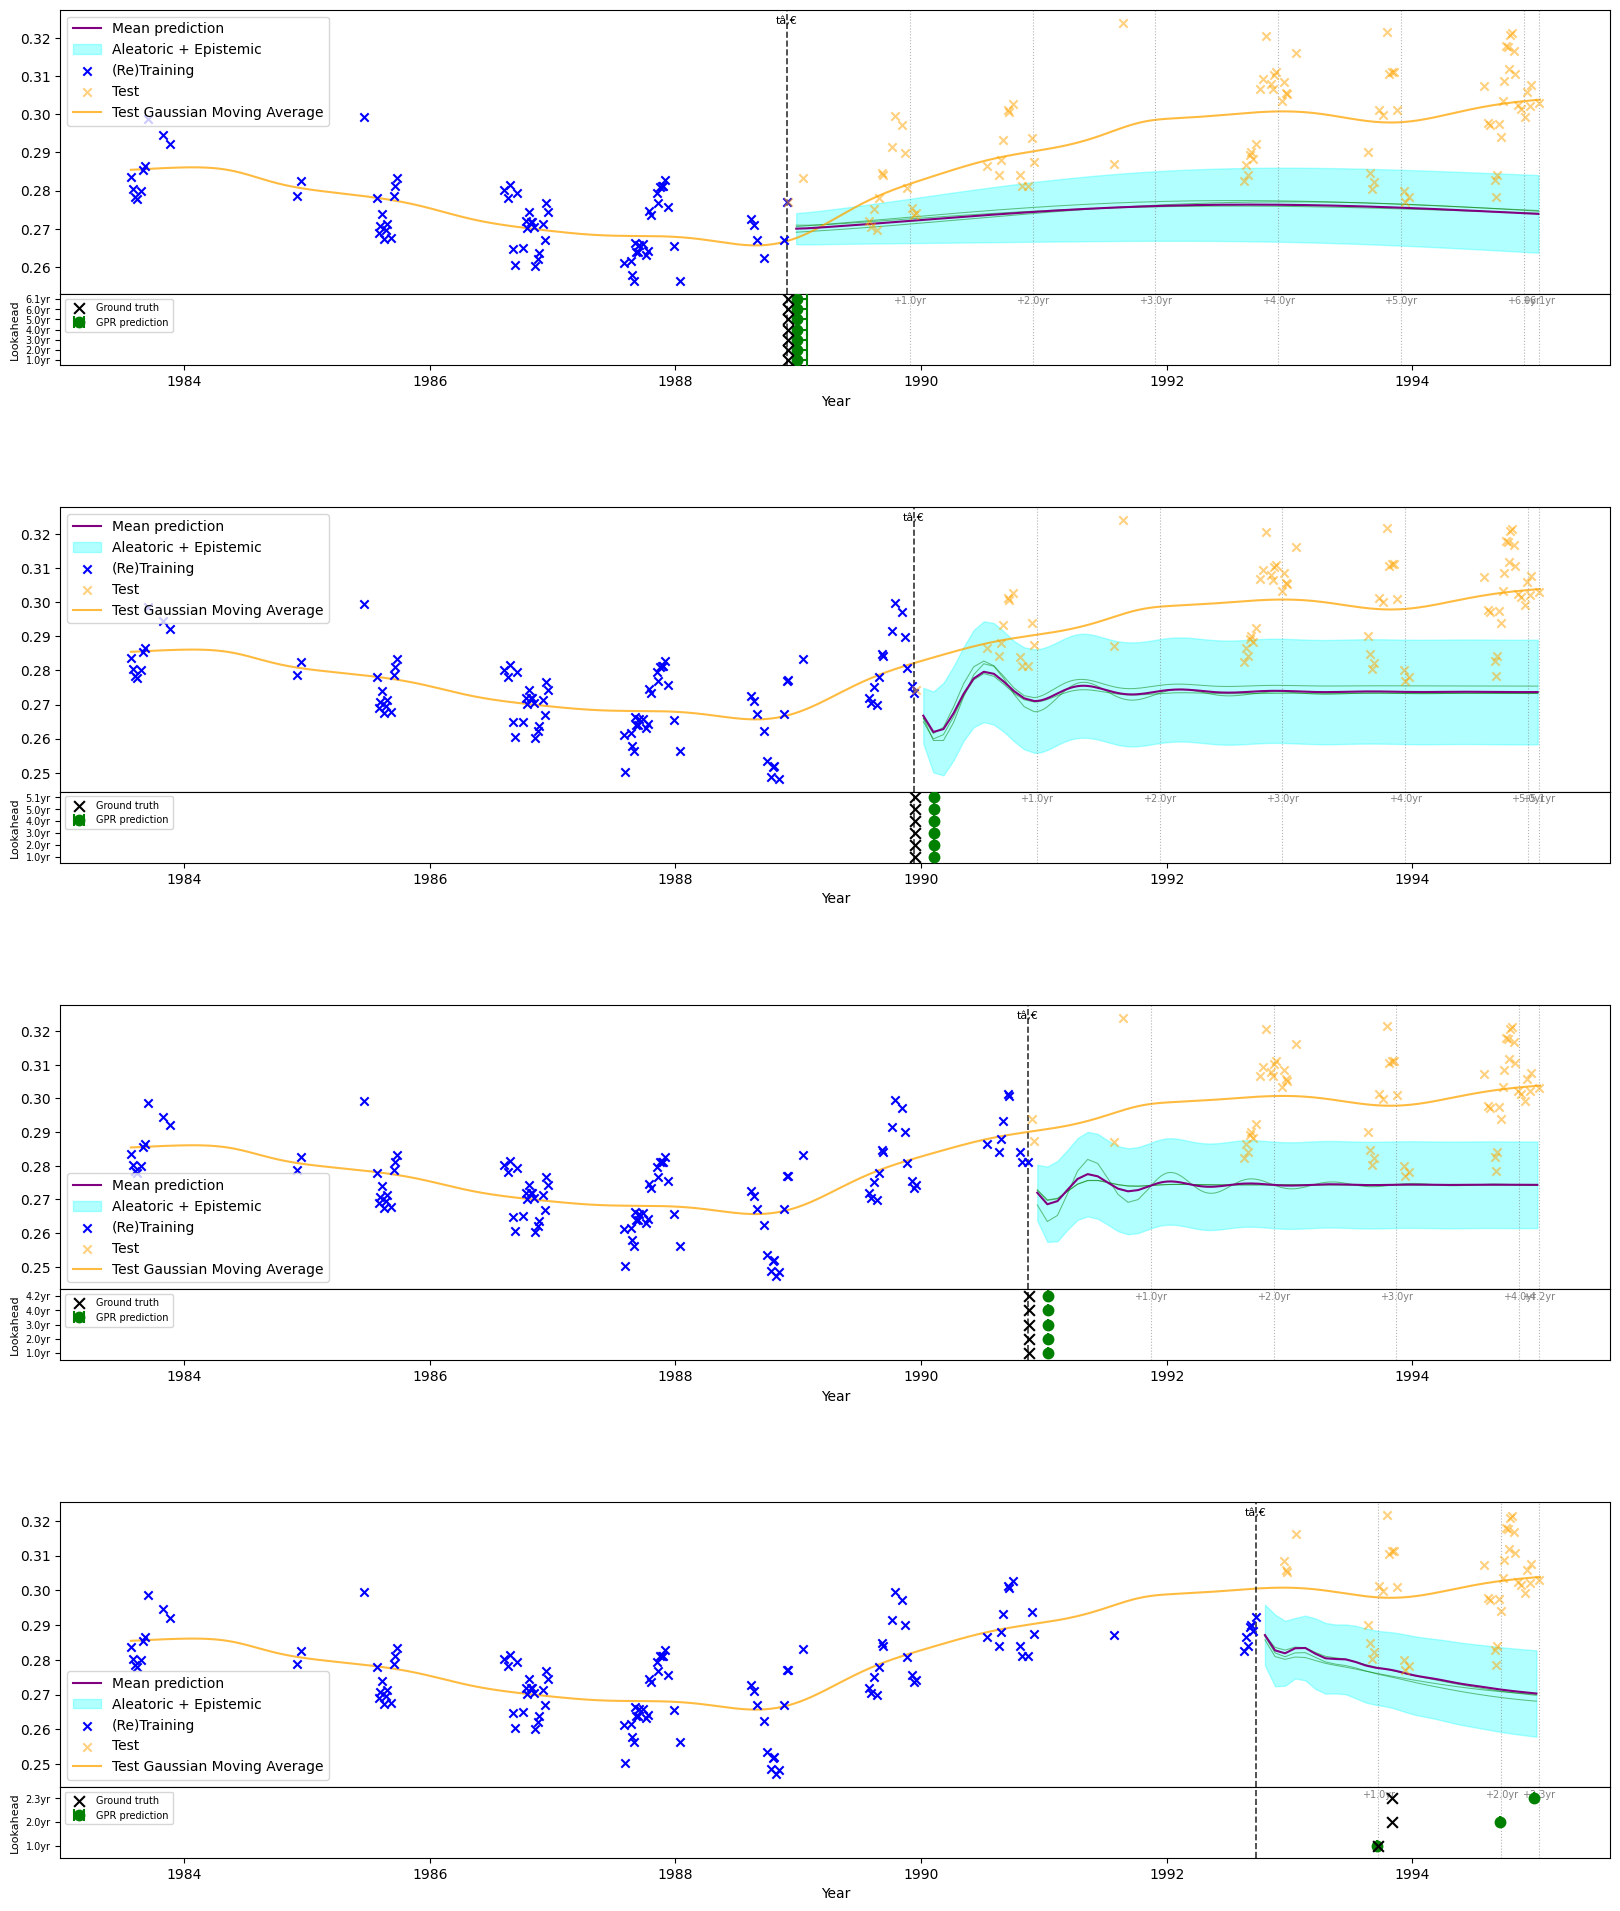

In [10]:
split_results = []

# Create the required subplots

import matplotlib.gridspec as gridspec

n_splits = len(train_splits)
fig = plt.figure(figsize=(20, 6 * n_splits))
outer_gs = gridspec.GridSpec(n_splits, 1, hspace=0.4, figure=fig)

axes = []
for i in range(n_splits):
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[i],
                                                height_ratios=[4, 1], hspace=0)
    ax = fig.add_subplot(inner_gs[0])
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax)
    axes.append((ax, ax2))

# LOOP

for train_split, valid_split, test_split, test_window_lens, (ax, ax2) in zip(train_splits, valid_splits, test_splits, test_window_lenss, axes):
    
    # Downsample
    data_df = downsample_min_gap(data_df, min_gap)

    #Split
    dirty_train_df, dirty_valid_df, test_df = split_df(data_df, train_split=train_split, valid_split=valid_split)

    # Clean
    train_df, valid_df, MAD = clean_df(dirty_train_df, dirty_valid_df, tol=4, verbose=verbose_clean, plot=plot_clean)

    #---LSP---
    classified_signal_data = find_classify_signals(dirty_train_df,
                                               plot_fitpeaks=plot_fitpeaks, verbose_fitpeaks=verbose_fitpeaks,
                                               plot_genpriors=plot_genpriors, verbose_genpriors=verbose_genpriors)

    rho_priors, rho_prior_bounds, rho_sources = get_priors(classified_signal_data,
                                                       star_type=star_type,
                                                       direct_bound_tol=direct_bound_tol,
                                                       sm2016_bound_tol=sm2016_bound_tol,
                                                       mean_bound_tol=mean_bound_tol,
                                                       verbose=verbose)
    
    #---Model comparison and selection---

    # Some required statistics
    train_yerr = train_df['sind'] * error_percent / 100
    train_mean = train_df['sind'].mean()
    train_std  = train_df['sind'].std()

    # kernel_types: list of 'sho' or 'matern' per term.
    # cycle_keys:   rho prior key per term (drives initial rho and bounds).
    # q_priors:     Q prior type for SHO terms ('overdamped' or None for underdamped).
    # param layout: [sigmas (all), rhos (all), qs (SHO only)]
    prior_combos = {
        "1m":    {'kernel_types': ['sho'],                      'cycle_keys': ['mid'],              'q_priors': None},
        "2sm":   {'kernel_types': ['sho', 'sho'],               'cycle_keys': ['short', 'mid'],     'q_priors': None},
        "2ml":   {'kernel_types': ['sho', 'sho'],               'cycle_keys': ['mid', 'long'],      'q_priors': None},
        "3sml":  {'kernel_types': ['sho', 'sho', 'sho'],        'cycle_keys': ['short', 'mid', 'long'], 'q_priors': None},
        "mat":   {'kernel_types': ['matern'],                   'cycle_keys': ['mid'],              'q_priors': None},
        "mat1m": {'kernel_types': ['matern', 'sho'],            'cycle_keys': ['mid', 'mid'],       'q_priors': None},
    }

    if require_mid:
        prior_combos = {key: val for key, val in prior_combos.items() if 'mid' in val['cycle_keys']}

    # Loop through combos
    combo_results = {}

    for combo_name, combo_info in prior_combos.items():
        kernel_types = combo_info['kernel_types']
        cycle_keys   = combo_info['cycle_keys']
        q_prior_type = combo_info['q_priors']

        n_terms = len(kernel_types)
        k_sho   = sum(1 for t in kernel_types if t == 'sho')

        # Repeatability
        np.random.seed(SEED)

        # Initial guesses
        q_0s     = ([np.random.uniform(0, 0.5) for _ in range(k_sho)] if q_prior_type == 'overdamped'
                    else [np.random.uniform(0.5, 1) for _ in range(k_sho)])
        sigma_0s = [train_std / n_terms for _ in range(n_terms)]
        rho_0s   = [rho_priors[ck] for ck in cycle_keys]

        initial_guess = np.concatenate([np.log(sigma_0s), np.log(rho_0s), np.log(q_0s)])

        # Bounds — reshape to (-1,2) so empty q_bounds stays 2D for concatenate
        q_bounds     = ([(-np.inf, np.log(0.5)) for _ in range(k_sho)] if q_prior_type == 'overdamped'
                        else [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k_sho)])
        sigma_bounds = [(np.log(1e-4), np.log(train_std * sigma_upper_mult)) for _ in range(n_terms)]
        rho_bounds   = np.log([rho_prior_bounds[ck] for ck in cycle_keys])
        bounds       = np.concatenate([
            np.array(sigma_bounds).reshape(-1, 2),
            np.array(rho_bounds).reshape(-1, 2),
            np.array(q_bounds).reshape(-1, 2),
        ])

        # Optimise over each inner_train_frac; keep params with best forward NLPD
        best_frac_nlpd   = np.inf
        best_frac_params = None
        best_frac_gp     = None

        for frac in inner_train_fracs:
            n_inner        = int(len(train_df) * frac)
            inner_train_df = train_df.iloc[:n_inner]
            inner_fwd_df   = train_df.iloc[n_inner:]
            inner_yerr_opt = inner_train_df['sind'] * error_percent / 100

            kernel_frac = build_kernel(
                np.concatenate([sigma_0s, rho_0s, q_0s]),
                kernel_types
            )
            gp_frac = celerite2.GaussianProcess(kernel_frac, mean=train_mean)
            gp_frac.compute(inner_train_df['day'], yerr=inner_yerr_opt)

            frac_result = minimize(forward_NLPD, initial_guess,
                                   args=(gp_frac, kernel_types, inner_train_df, inner_fwd_df, error_percent),
                                   method='L-BFGS-B', bounds=bounds)

            if frac_result.fun < best_frac_nlpd:
                best_frac_nlpd   = frac_result.fun
                best_frac_params = frac_result.x
                gp_frac = set_params(frac_result.x, kernel_types, gp_frac)
                gp_frac.compute(train_df['day'], yerr=train_yerr)
                best_frac_gp = gp_frac

        gp          = best_frac_gp
        best_params = np.exp(best_frac_params)

        # Calculate the performance on the validation set
        mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        y_valid    = valid_df['sind'].to_numpy()
        valid_yerr = valid_df['sind'] * error_percent / 100
        total_std  = np.sqrt(cov + valid_yerr**2)

        # Calculate the NLPD based on those performance stats
        total_var      = cov + valid_yerr**2
        nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
        mean_nlpd      = nlpd_per_point.mean()

        # Calculate the CRPS based on those performance stats
        z        = (y_valid - mu) / total_std
        crps     = total_std * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1/np.sqrt(np.pi))
        mean_crps = crps.mean()

        # Save the results
        combo_results[combo_name] = {
            "NLPD": mean_nlpd, "CRPS": mean_crps,
            "gp": gp, "params": best_params,
            "kernel_types": kernel_types,
            "initial_guess": initial_guess, "bounds": bounds,
        }

        # Plot and print
        if verbose_comparison:
            best_sigmas = best_params[:n_terms]
            best_rhos   = best_params[n_terms:2*n_terms]
            best_qs     = best_params[2*n_terms:]
            table = PrettyTable(["type", "sigma", "Q", "rho (days)", "rho (years)"])
            sho_idx = 0
            for i, ktype in enumerate(kernel_types):
                q_str = f"{best_qs[sho_idx]:.2f}" if ktype == 'sho' else "-"
                if ktype == 'sho':
                    sho_idx += 1
                table.add_row([ktype, f"{best_sigmas[i]:.4f}", q_str,
                                f"{best_rhos[i]:.2f}", f"{best_rhos[i]/365:.2f}"])
            print(f"{combo_name} | CRPS={mean_crps:.4f} | NLPD={mean_nlpd:.4f}")
            print(table)

        if plot_comparison:
            loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
            loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
            loop_ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
            loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
            loop_ax.fill_between(valid_df['year'], mu - total_std, mu + total_std, color='green', alpha=0.2)
            loop_ax.set_title(f"{star_name} {combo_name}")
            loop_ax.legend()
            plt.show()
    
    #---Selecting Model---
    lowest_valid_metric = np.inf
    best_combo_name     = None
    for combo_name, combo_result in combo_results.items():
        if combo_result[valid_metric] < lowest_valid_metric:
            lowest_valid_metric  = combo_result[valid_metric]
            best_combo_name      = combo_name
            best_gp              = combo_result['gp']
            best_params          = combo_result['params']
            best_kernel_types    = combo_result['kernel_types']
            best_initial_guess   = combo_result['initial_guess']
            best_bounds          = combo_result['bounds']

    if verbose_selected:
        print(f"Selected model: {best_combo_name} ({valid_metric}={lowest_valid_metric:.4f})")

    #---Retraining---

    # Combine the datasets
    retrain_df = downsample_min_gap(pd.concat([train_df, valid_df]), minimum_gap)

    # Getting the winning model info
    combo_info   = prior_combos[best_combo_name]
    kernel_types = combo_info['kernel_types']
    cycle_keys   = combo_info['cycle_keys']
    n_terms      = len(kernel_types)

    # Redefining the statistics
    retrain_yerr = retrain_df['sind'] * error_percent / 100
    retrain_mean = retrain_df['sind'].mean()

    # Initial guesses as the best params from first optimisation
    initial_guess = np.log(best_params)  # back to log space for the optimiser

    # Optimise over each inner_train_frac; keep params with best forward NLPD
    best_frac_nlpd       = np.inf
    best_frac_params     = None
    best_frac_gp_retrain = None

    for frac in inner_train_fracs:
        n_inner_retrain      = int(len(retrain_df) * frac)
        inner_retrain_df     = retrain_df.iloc[:n_inner_retrain]
        inner_retrain_fwd_df = retrain_df.iloc[n_inner_retrain:]
        inner_retrain_yerr   = inner_retrain_df['sind'] * error_percent / 100

        kernel_frac = build_kernel(best_params, kernel_types)
        gp_frac = celerite2.GaussianProcess(kernel_frac, mean=retrain_mean)
        gp_frac.compute(inner_retrain_df['day'], yerr=inner_retrain_yerr)

        frac_result = minimize(forward_NLPD, initial_guess,
                               args=(gp_frac, kernel_types, inner_retrain_df, inner_retrain_fwd_df, error_percent),
                               method='L-BFGS-B', bounds=best_bounds)

        if frac_result.fun < best_frac_nlpd:
            best_frac_nlpd       = frac_result.fun
            best_frac_params     = frac_result.x
            gp_frac = set_params(frac_result.x, kernel_types, gp_frac)
            gp_frac.compute(retrain_df['day'], yerr=retrain_yerr)
            best_frac_gp_retrain = gp_frac

    gp_retrain    = best_frac_gp_retrain
    retrain_params = np.exp(best_frac_params)

    #---MCMC on retrained---
    np.random.seed(SEED)

    y = retrain_df['sind'].to_numpy()

    walker_start_coords = np.log(retrain_params) + 1e-5 * np.random.randn(n_walkers, len(retrain_params))

    sampler = emcee.EnsembleSampler(n_walkers, len(retrain_params), lnPost,
                    args=(gp_retrain, kernel_types, y, best_frac_params, best_bounds))
    sampler.run_mcmc(walker_start_coords, nsteps=total_sample_count, progress=True)

    if plot_sampler:
        param_names = (
            [f'sigma_{ck}' for ck in cycle_keys] +
            [f'rho_{ck}'   for ck in cycle_keys] +
            [f'Q_{ck}' for ck, kt in zip(cycle_keys, kernel_types) if kt == 'sho']
        )
        plot_trace(sampler, param_names)

    ln_chains = sampler.get_chain(discard=1000)
    ln_samples = ln_chains.reshape(-1, ln_chains.shape[-1])

    np.random.seed(SEED)
    idx = np.random.choice(len(ln_samples), size=subsample, replace=False)
    ln_samples = ln_samples[idx]

    #---Predict the retrained_gp---
    
    # Define the prediction grid
    t0_day = retrain_df['day'].iloc[0]
    t0_year = retrain_df['year'].iloc[0]

    t_pred_start = retrain_df['day'].iloc[-1]
    t_pred_start_year = retrain_df['year'].iloc[-1]
    t_ring_end = t_pred_start + 365  # End of low cadence
    t_pred_end = max(retrain_df['day'].iloc[-1] + 365 * pred_forward_years, test_df['day'].iloc[-1])

    # Extend grid back 6 months into training (low cadence) for smooth visual connection at t0
    t_lookback_start = t_pred_start - 365 * 0.5
    sampled_days = np.concatenate([
        np.arange(t_lookback_start, t_ring_end, low_cad),
        np.arange(t_ring_end, t_pred_end, high_cad)
    ])
    
    sampled_years = t0_year + (sampled_days - t0_day)/365.25 # For plotting

    # Build posterior sample set
    preds, pred_vars = [], []

    for i, ln_sample in enumerate(ln_samples):
        set_params(ln_sample, kernel_types, gp_retrain)
        gp_retrain.recompute(quiet=True)
        pred, pred_var = gp_retrain.predict(retrain_df['sind'], t=sampled_days, return_var=True)
        preds.append(pred)
        pred_vars.append(pred_var)
        if (i + 1) % 100 == 0:
            print(f"{i + 1}/{len(ln_samples)}")

    #---Posterior sample statistics---
    
    def to_year(day):
        return t0_year + (day - t0_day) / 365

    preds = np.array(preds)
    pred_vars = np.array(pred_vars)

    mean_pred = preds.mean(axis=0)

    # Check if const
    is_const = check_constant(preds, MAD)

    # Append full span now that t_pred_start_year is known from the cleaned retrain set
    test_window_lens = np.append(test_window_lens, data_df['year'].iloc[-1] - t_pred_start_year)

    # Check windows â€" t_start=t_pred_start so lookahead is measured from t0, not the lookback
    best_ins = [best_in_x(predictions=preds, t=sampled_days, lookahead_years=test_window_len,
                          t_start=t_pred_start) for test_window_len in test_window_lens]

    # Get window ground truths (single point, recency-weighted)
    window_truths = [truth_in_x(data_df, t0_year, t0_day, t_pred_start_year, test_window_len,
                                pred_start_day=t_pred_start) for test_window_len in test_window_lens]

    # Create the Gaussian smoothing to plot (sigma = 6 months)
    t_day_smooth, y_smooth = gaussian_smooth(data_df['day'].values, data_df['sind'].values, sigma=182.5)
    t_year_smooth = to_year(t_day_smooth)

    #---Plot this stuff---

    # Calculate errors
    aleatoric = pred_vars.mean(axis=0) # Random noise
    epistemic = preds.var(axis=0) # Uncertainty in the model params 
    total_std = np.sqrt(aleatoric + epistemic)

    plot_mask = sampled_years >= t_pred_start_year

    # Main forecast panel: Plot some samples (post-t0 only)
    for idx, pred in enumerate(preds):
        if idx % plot_every == 0:
            ax.plot(sampled_years[plot_mask], pred[plot_mask], color='green', alpha=0.5, lw=0.75)

    # Main: Plot mean and uncs (post-t0 only)
    ax.plot(sampled_years[plot_mask], mean_pred[plot_mask], color='purple', label='Mean prediction', zorder=3)
    ax.fill_between(sampled_years[plot_mask],
                mean_pred[plot_mask] - total_std[plot_mask],
                mean_pred[plot_mask] + total_std[plot_mask],
                color='cyan', alpha=0.3, label='Aleatoric + Epistemic', zorder=1)

    # Main: Plot datasets
    ax.scatter(retrain_df['year'], retrain_df['sind'], color='blue', label='(Re)Training', marker='x', zorder=4)
    ax.scatter(test_df['year'], test_df['sind'], color='orange', label='Test', marker='x', alpha=0.5, zorder=4)

    # Main: Gaussian smoothed
    ax.plot(t_year_smooth, y_smooth, label="Test Gaussian Moving Average", color="orange", alpha=0.75)

    # Both: t0 line
    for a in (ax, ax2):
        a.axvline(t_pred_start_year, color='black', linestyle='--', lw=1.2, alpha=0.8, zorder=3)
    ax.text(t_pred_start_year, 0.98, 'tâ‚€', transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=8)

    # Both: window boundaries
    n_windows = len(test_window_lens)
    for w_len in test_window_lens:
        for a in (ax, ax2):
            a.axvline(t_pred_start_year + w_len, color='gray', linestyle=':', lw=0.8, alpha=0.6, zorder=2)
        ax2.text(t_pred_start_year + w_len, n_windows - 0.15, f'+{w_len:.1f}yr', ha='center', va='top', fontsize=7, color='gray')

    # Lookahead panel: ground truth (single point, no uncertainty)
    for i, med in enumerate(window_truths):
        if not np.isnan(med):
            ax2.scatter(med, i + 0.5, marker='x', color='black', s=60, linewidths=1.5,
                        zorder=5, label='Ground truth' if i == 0 else '_nolegend_')

    # Lookahead panel: GPR predictions
    for i, (med_day, (lb_day, hb_day)) in enumerate(best_ins):
        med = to_year(med_day)
        lb  = to_year(lb_day)
        hb  = to_year(hb_day)
        ax2.errorbar(med, i + 0.5,
                    xerr=[[med - lb], [hb - med]],
                    fmt='o', color='green', capsize=4, capthick=1.5,
                    elinewidth=1.5, markersize=7, markeredgewidth=1.5,
                    label='GPR prediction' if i == 0 else '_nolegend_',
                    zorder=4)
    ax2.legend(fontsize=7)

    ax2.set_ylim(0, n_windows)
    ax2.set_yticks([i + 0.5 for i in range(n_windows)])
    ax2.set_yticklabels([f'{w:.1f}yr' for w in test_window_lens], fontsize=7)
    ax2.set_ylabel("Lookahead", fontsize=8)
    ax2.set_xlabel("Year")
    ax.legend()

    #---Print---
    table = PrettyTable(["Label", "Search from", "Search to", "Ground truth"])
    table.align = "r"
    table.align["Label"] = "l"

    for w_len, med in zip(test_window_lens, window_truths):
        if np.isnan(med):
            table.add_row([f"Best in +{w_len:.1f}yr", f"{t_pred_start_year:.2f}", f"{t_pred_start_year + w_len:.2f}", "not found"])
        else:
            table.add_row([f"Best in +{w_len:.1f}yr", f"{t_pred_start_year:.2f}", f"{t_pred_start_year + w_len:.2f}", f"{med:.2f}"])

    print(table)

    #---Save---
    is_constant = is_const
    split_results.append({
      'best_combo_name': best_combo_name,
      'best_params': best_params,
      'gp': gp,
      'mean_pred': mean_pred,
      'aleatoric': aleatoric,
      'epistemic': epistemic,
      'total_std': total_std,
      'is_constant': is_constant,
      'window_truths': window_truths,
      'best_ins': best_ins,
      })

In [11]:
import pickle

with open("split_results.pkl", "wb") as f:
    pickle.dump(split_results, f)